## Psych 186B Final Project: Chest X-Ray Classification

Cynthia Du, Angelina Pace

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import cv2

from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from sklearn.utils.class_weight import compute_class_weight
import shutil
from google.colab import drive
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
import time
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia
['chest_xray']


In [ ]:
base_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"

def process_images_to_df(dataset_type, img_size=128):
    path = os.path.join(base_path, dataset_type)
    data = []

    # Mapping labels to numbers: Normal=0, Pneumonia=1
    categories = {'NORMAL': 0, 'PNEUMONIA': 1}

    for label, value in categories.items():
        folder_path = os.path.join(path, label)
        if not os.path.exists(folder_path):
            continue

        for file in os.listdir(folder_path):
            if file.endswith(('.jpeg', '.jpg', '.png')):
                try:
                    full_path = os.path.join(folder_path, file)

                    # Load, resize, and convert to RGB
                    img = cv2.imread(full_path)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (img_size, img_size))

                    # Normalize pixel values to [0, 1]
                    img = img / 255.0

                    data.append([img, value])
                except Exception as e:
                    pass # Skip corrupted files

    return pd.DataFrame(data, columns=['image', 'label'])

# Execute for all three sets
train_df = process_images_to_df('train')
test_df = process_images_to_df('test')
val_df = process_images_to_df('val')

print("Done!")

Done!


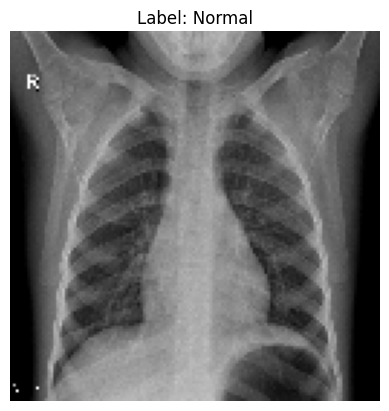

In [ ]:
# Check a random image from the training set
sample_idx = 5
plt.imshow(train_df['image'][sample_idx])
plt.title(f"Label: {'Pneumonia' if train_df['label'][sample_idx] == 1 else 'Normal'}")
plt.axis('off')
plt.show()

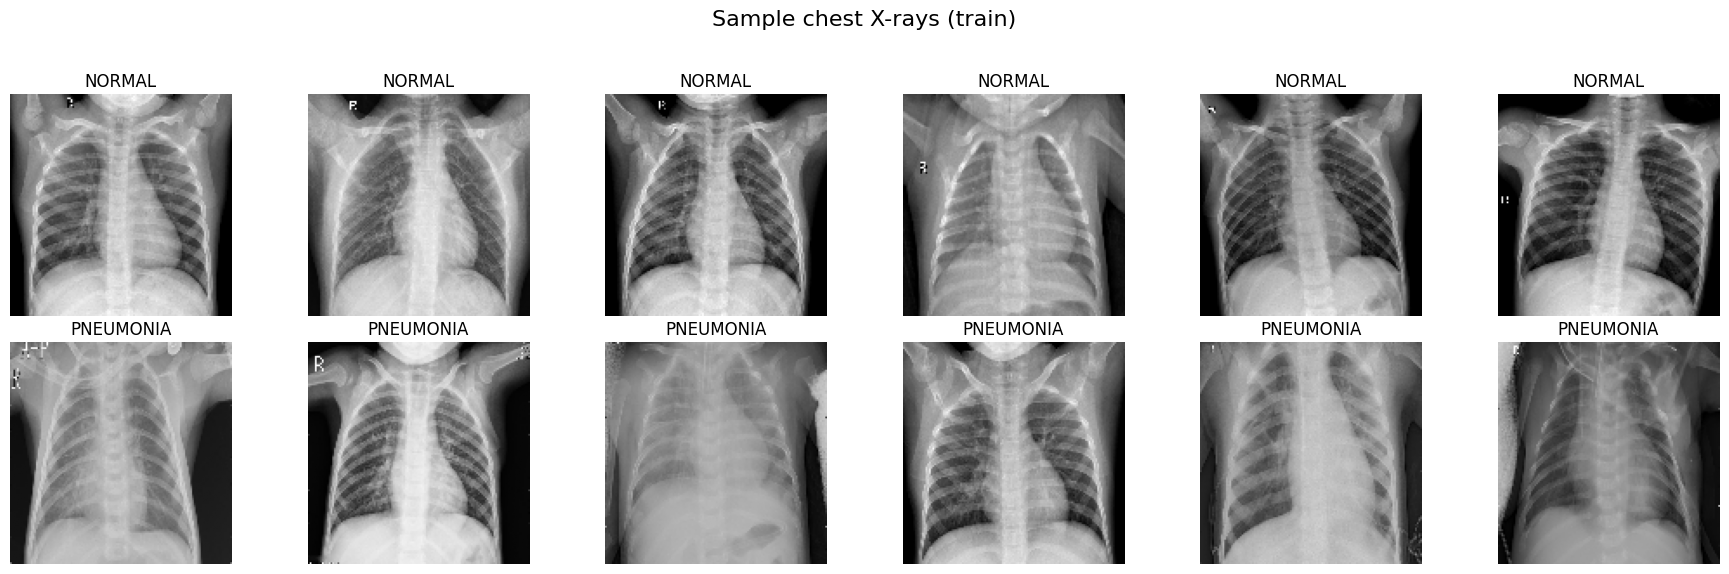

In [ ]:
def plot_samples(df, n_samples=6):
    normal_samples = df[df['label'] == 0].sample(n_samples)
    pneumonia_samples = df[df['label'] == 1].sample(n_samples)

    fig, axes = plt.subplots(2, n_samples, figsize=(18, 6))
    plt.suptitle('Sample chest X-rays (train)', fontsize=16)

    for i in range(n_samples):
        # Plot Normal images on top row
        axes[0, i].imshow(normal_samples.iloc[i]['image'])
        axes[0, i].set_title("NORMAL")
        axes[0, i].axis('off')

        # Plot Pneumonia images on bottom row
        axes[1, i].imshow(pneumonia_samples.iloc[i]['image'])
        axes[1, i].set_title("PNEUMONIA")
        axes[1, i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_samples(train_df)

### Exploratory Data Analysis

In [ ]:
X_train = np.stack(train_df['image'].values)
y_train = train_df['label'].values

X_test = np.stack(test_df['image'].values)
y_test = test_df['label'].values

X_val = np.stack(val_df['image'].values)
y_val = val_df['label'].values

In [ ]:
# Check features (X) and labels (y)
print(f"Train images shape: {X_train.shape}")
print(f"Train labels shape: {y_train.shape}")

print(f"Test images shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

print(f"Val images shape: {X_val.shape}")
print(f"Val labels shape: {y_val.shape}")

Train images shape: (5216, 128, 128, 3)
Train labels shape: (5216,)
Test images shape: (624, 128, 128, 3)
Test labels shape: (624,)
Val images shape: (16, 128, 128, 3)
Val labels shape: (16,)


In [ ]:
# Check how many images are 'Normal' (0) and 'Pneumonia' (1)

train_counts = train_df['label'].value_counts().reset_index()
train_counts['split'] = 'train'

test_counts = test_df['label'].value_counts().reset_index()
test_counts['split'] = 'test'

val_counts = val_df['label'].value_counts().reset_index()
val_counts['split'] = 'val'

summary_table = pd.concat([test_counts, train_counts, val_counts], ignore_index=True)

summary_table.columns = ['class_name', 'count', 'split']
summary_table['class_name'] = summary_table['class_name'].map({0: 'NORMAL', 1: 'PNEUMONIA'})

summary_table = summary_table[['split', 'class_name', 'count']]

summary_table

,split,class_name,count
0,test,PNEUMONIA,390
1,test,NORMAL,234
2,train,PNEUMONIA,3875
3,train,NORMAL,1341
4,val,NORMAL,8
5,val,PNEUMONIA,8


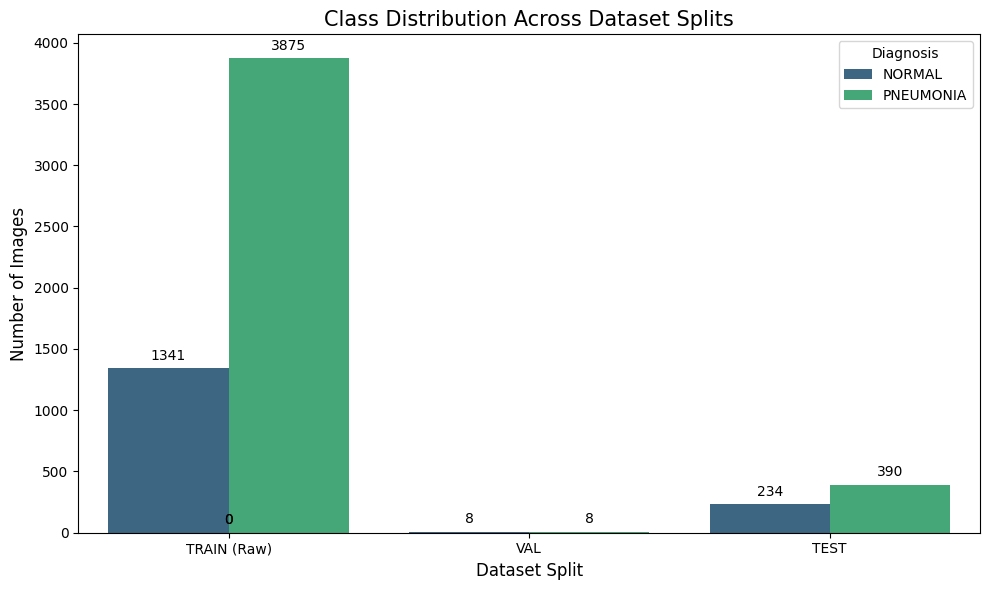

In [ ]:
def plot_class_imbalance(df_list, names):
    # 1. Prepare data for plotting
    plot_data = []
    for df, name in zip(df_list, names):
        counts = df['label'].value_counts().sort_index()
        plot_data.append({'Split': name, 'Class': 'NORMAL', 'Count': counts.get(0, 0)})
        plot_data.append({'Split': name, 'Class': 'PNEUMONIA', 'Count': counts.get(1, 0)})

    viz_df = pd.DataFrame(plot_data)

    # 2. Create the plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=viz_df, x='Split', y='Count', hue='Class', palette='viridis')

    # 3. Add labels and title
    plt.title('Class Distribution Across Dataset Splits', fontsize=15)
    plt.xlabel('Dataset Split', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.legend(title='Diagnosis')

    # Add count labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()
    plt.show()

# Run the visualization for your Raw Training, Validation, and Test sets
plot_class_imbalance(
    [train_df, val_df, test_df],
    ["TRAIN (Raw)", "VAL", "TEST"]
)

The data splits reveal a class imbalance in the training set, where "Pneumonia" cases outnumber "Normal" cases by nearly three to one. This distribution suggests that a model trained on this data might develop a bias toward predicting pneumonia simply because it appears more frequently.

Furthermore, the validation set is small with only 16 total images, which represents less than 1% of the total dataset. This small sample size makes it difficult to reliably tune hyperparameters, as the validation metrics will be highly sensitive to even a single incorrect prediction.

In [ ]:
shapes = np.array([img.shape for img in train_df['image']])
widths = shapes[:, 1]
heights = shapes[:, 0]

# Extract pixel intensity values
all_pixels = np.concatenate([img.flatten() for img in train_df['image']])

print("Processed Image Dimensions (After Resizing):")
print(f"Uniform Shape: {train_df['image'][0].shape}")
print(f"Total Pixels per Image: {train_df['image'][0].size}")

print("\nPixel Intensity Statistics (Scaled 0-1):")
print(f"Min Intensity: {all_pixels.min():.4f}")
print(f"Max Intensity: {all_pixels.max():.4f}")
print(f"Mean Intensity: {all_pixels.mean():.4f}")
print(f"Std Deviation: {all_pixels.std():.4f}")

Processed Image Dimensions (After Resizing):
Uniform Shape: (128, 128, 3)
Total Pixels per Image: 49152

Pixel Intensity Statistics (Scaled 0-1):
Min Intensity: 0.0000
Max Intensity: 1.0000
Mean Intensity: 0.4819
Std Deviation: 0.2374


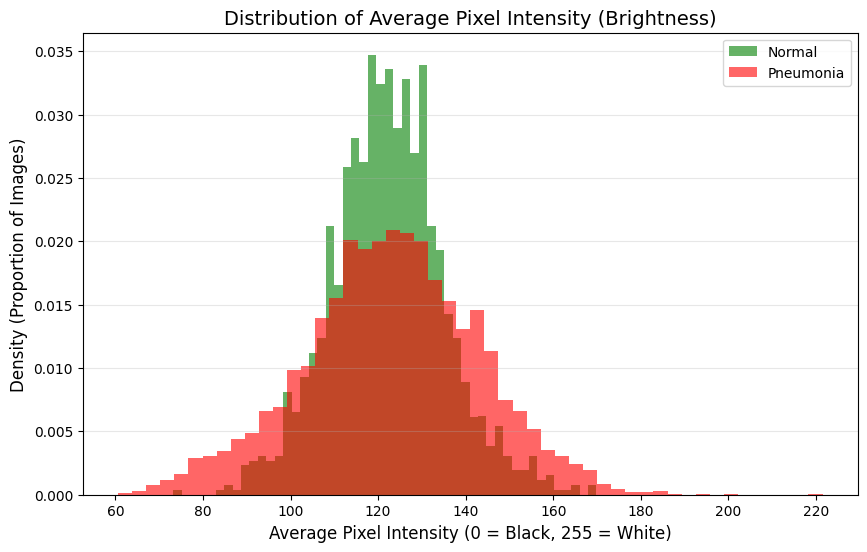

Mean Brightness - Normal: 122.26
Mean Brightness - Pneumonia: 123.10


In [ ]:
def get_brightness_list(df, label_value):
    return [np.mean(img) * 255 for img in df[df['label'] == label_value]['image']]

normal_brightness = get_brightness_list(train_df, 0)
pneumonia_brightness = get_brightness_list(train_df, 1)

plt.figure(figsize=(10, 6))

plt.hist(normal_brightness, bins=50, alpha=0.6, color='green', label='Normal', density=True)
plt.hist(pneumonia_brightness, bins=50, alpha=0.6, color='red', label='Pneumonia', density=True)

plt.title('Distribution of Average Pixel Intensity (Brightness)', fontsize=14)
plt.xlabel('Average Pixel Intensity (0 = Black, 255 = White)', fontsize=12)
plt.ylabel('Density (Proportion of Images)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

print(f"Mean Brightness - Normal: {np.mean(normal_brightness):.2f}")
print(f"Mean Brightness - Pneumonia: {np.mean(pneumonia_brightness):.2f}")

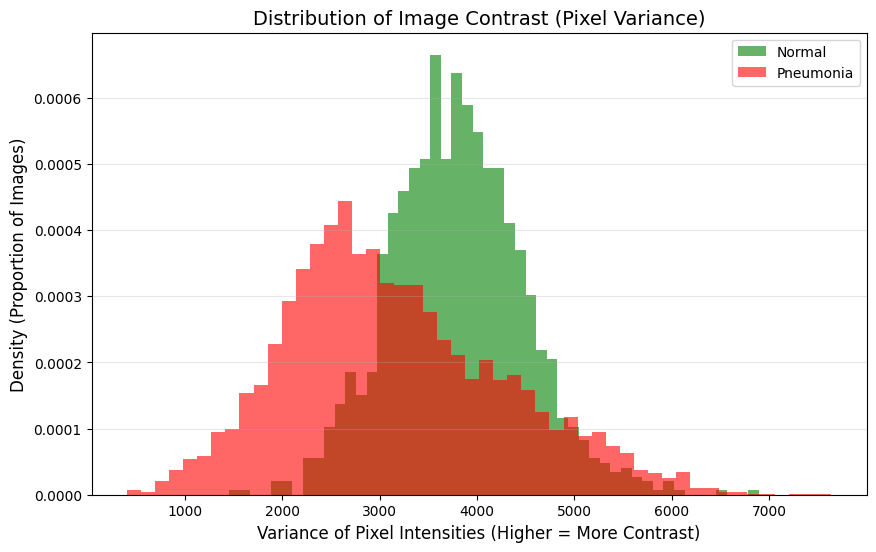

Mean Contrast - Normal: 3795.34
Mean Contrast - Pneumonia: 3155.10


In [ ]:
# Calculate variance (contrast) from the DataFrame
def get_contrast_list(df, label_value):
    return [np.var(img * 255) for img in df[df['label'] == label_value]['image']]

# Compute contrast for each class
normal_contrast = get_contrast_list(train_df, 0)
pneumonia_contrast = get_contrast_list(train_df, 1)

plt.figure(figsize=(10, 6))

plt.hist(normal_contrast, bins=50, alpha=0.6, color='green', label='Normal', density=True)
plt.hist(pneumonia_contrast, bins=50, alpha=0.6, color='red', label='Pneumonia', density=True)

plt.title('Distribution of Image Contrast (Pixel Variance)', fontsize=14)
plt.xlabel('Variance of Pixel Intensities (Higher = More Contrast)', fontsize=12)
plt.ylabel('Density (Proportion of Images)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

print(f"Mean Contrast - Normal: {np.mean(normal_contrast):.2f}")
print(f"Mean Contrast - Pneumonia: {np.mean(pneumonia_contrast):.2f}")

Contrast measures variation in pixel intensity (variance/std dev of pixel intensities). Overall, we can see that there is a huge difference here between contrast. Pneumonia's average contrast is lower than that of normal x-ray images. This can be interpreted as saying that the pneumonia x-rays are generally less sharp, making the image appear more hazy or cloudy. We can also see that the data for Pneumonia is also skewed right, showing that while many pneumonia images have low contrast, a smaller subset of them have unusually higher variance.

### Data Preprocessing

A big issue with our dataset is that the validation set is very small, and the training and test datasets are highly imbalanced. As a result, we aim to balance these to make the data more usable for the model.

In [ ]:
from IPython.display import display, HTML
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Combine original train + val
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

# Create new stratified split (15% for a statistically significant validation set)
train_df_new, val_df_new = train_test_split(
    trainval_df,
    test_size=0.15,
    random_state=42,
    stratify=trainval_df["label"]
)

# Undersampling function to balance classes 50/50
def balance_train_df_undersample(df, seed=42):
    df0 = df[df['label'] == 0]
    df1 = df[df['label'] == 1]
    n_min = min(len(df0), len(df1))

    df0_bal = df0.sample(n=n_min, random_state=seed)
    df1_bal = df1.sample(n=n_min, random_state=seed)

    return pd.concat([df0_bal, df1_bal]).sample(frac=1, random_state=seed).reset_index(drop=True)

train_df_bal = balance_train_df_undersample(train_df_new)


# REPORTING NEW DATASETS

def display_class_stats_table(df_list, names):
    summary_data = []
    for df, name in zip(df_list, names):
        counts = df['label'].value_counts().sort_index()
        total = len(df)
        summary_data.append({
            'Split': name,
            'NORMAL (0)': counts.get(0, 0),
            'PNEUMONIA (1)': counts.get(1, 0),
            'Total': total,
            'Pneumonia %': f"{(counts.get(1, 0)/total)*100:.1f}%"
        })
    display(pd.DataFrame(summary_data))

display(HTML("<h3>Dataset Distribution Summary</h3>"))
display_class_stats_table(
    [train_df_new, train_df_bal, val_df_new, test_df],
    ["TRAIN (Raw)", "TRAIN (Balanced)", "VAL", "TEST"]
)

# TENSOR CONVERSION

# Stacking images into 4D NumPy arrays for the Neural Network
X_train = np.stack(train_df_bal['image'].values).astype(np.float32)
y_train = train_df_bal['label'].values.astype(np.float32)

X_val = np.stack(val_df_new['image'].values).astype(np.float32)
y_val = val_df_new['label'].values.astype(np.float32)

X_test = np.stack(test_df['image'].values).astype(np.float32)
y_test = test_df['label'].values.astype(np.float32)

display(HTML("<h3>Final Tensor Dimensions</h3>"))
shape_data = [
    {"Array": "X_train", "Shape": str(X_train.shape), "Purpose": "Training Features"},
    {"Array": "X_val", "Shape": str(X_val.shape), "Purpose": "Validation Features"},
    {"Array": "X_test", "Shape": str(X_test.shape), "Purpose": "Testing Features"}
]
display(pd.DataFrame(shape_data))

# DATA PIPELINE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.10),
])

def make_dataset(X, y, training=False, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X))
    ds = ds.map(
        lambda x, y: (data_augmentation(x, training=True), y)
        if training else (x, y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

print("\nData pipeline complete and ready for training.")

,Split,NORMAL (0),PNEUMONIA (1),Total,Pneumonia %
0,TRAIN (Raw),1147,3300,4447,74.2%
1,TRAIN (Balanced),1147,1147,2294,50.0%
2,VAL,202,583,785,74.3%
3,TEST,234,390,624,62.5%


,Array,Shape,Purpose
0,X_train,"(2294, 128, 128, 3)",Training Features
1,X_val,"(785, 128, 128, 3)",Validation Features
2,X_test,"(624, 128, 128, 3)",Testing Features



Data pipeline complete and ready for training.


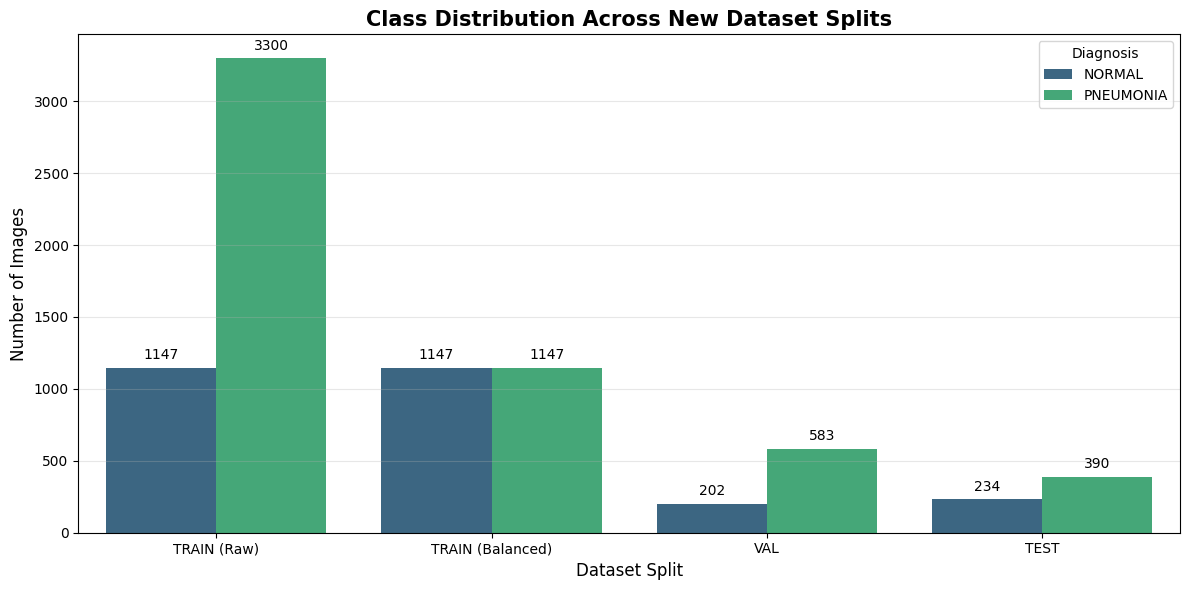

In [ ]:
def plot_new_class_distribution(df_list, names):
    # 1. Prepare data for plotting
    plot_data = []
    for df, name in zip(df_list, names):
        counts = df['label'].value_counts().sort_index()
        plot_data.append({'Split': name, 'Class': 'NORMAL', 'Count': counts.get(0, 0)})
        plot_data.append({'Split': name, 'Class': 'PNEUMONIA', 'Count': counts.get(1, 0)})

    viz_df = pd.DataFrame(plot_data)

    # 2. Create the plot
    plt.figure(figsize=(12, 6))

    # Using 'viridis' to match the color scheme of your previous chart
    ax = sns.barplot(data=viz_df, x='Split', y='Count', hue='Class', palette='viridis')

    # 3. Add labels and title
    plt.title('Class Distribution Across New Dataset Splits', fontsize=15, fontweight='bold')
    plt.xlabel('Dataset Split', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.legend(title='Diagnosis')

    # 4. Add count labels on top of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Only annotate bars that have a value
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points',
                        fontsize=10)

    # Add a subtle grid for easier reading
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the visualization for your four specific datasets
plot_new_class_distribution(
    [train_df_new, train_df_bal, val_df_new, test_df],
    ["TRAIN (Raw)", "TRAIN (Balanced)", "VAL", "TEST"]
)

To address the critical issues of a small validation set and highly imbalanced data, this workflow implements a more robust preprocessing strategy. By merging the original training and validation sets and performing a stratified split, we ensure that 15% of the data is reserved for a statistically significant validation set that mirrors the true distribution of the classes. To prevent the model from developing a bias toward the majority "Pneumonia" class, we apply undersampling to the training set, effectively balancing the labels to a 50/50 ratio. Finally, this balanced data is converted into high-performance TensorFlow datasets that incorporate data augmentation, such as random rotations and contrast shifts, to enhance the model's ability to generalize to new, unseen chest X-rays.

### Modeling

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Helps prevent overfitting
    layers.Dense(1, activation='sigmoid') # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


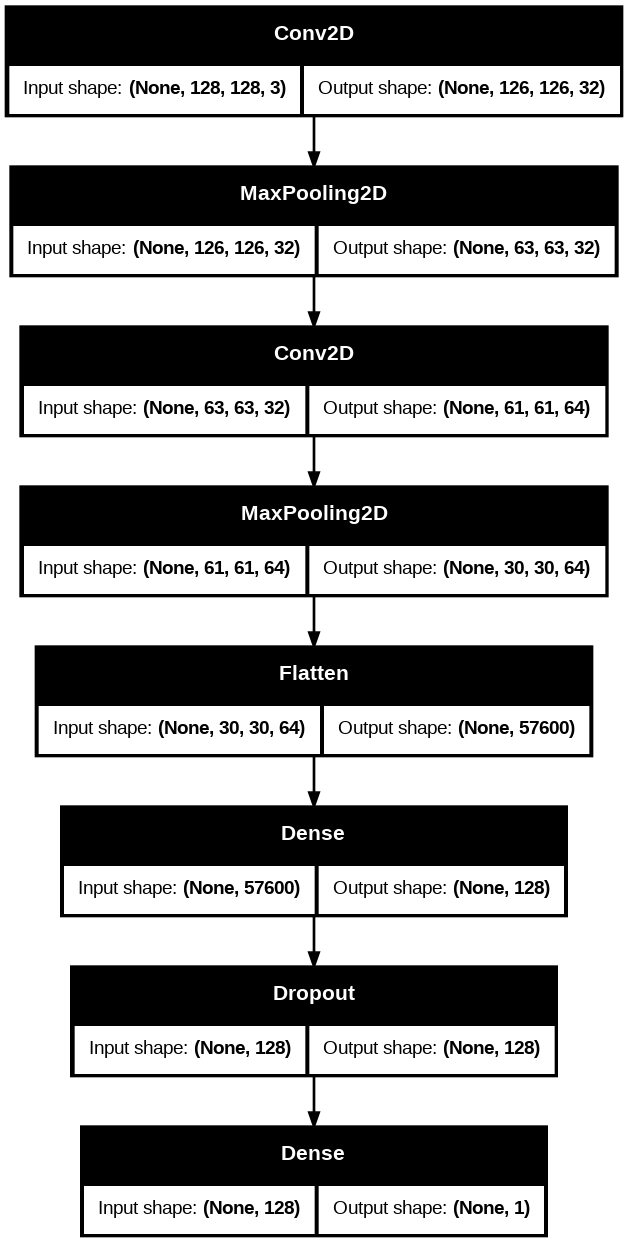

In [ ]:
from tensorflow.keras.utils import plot_model

# rankdir='LR' makes it horizontal, perfect for slides
# dpi=96 keeps the image crisp but not overly massive
plot_model(
    model,
    to_file='cnn_architecture_slide.png',
    show_shapes=True,
    show_layer_names=False,
    # rankdir='LR',
    dpi=96
)

### mirror images to challenge the model - testing data

In [ ]:
# TRAINING

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

print("\nEvaluation on ORIGINAL test set:")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy (original): {test_acc:.4f}")

# MIRROR TEST IMAGES (left-right flip)

X_test_mirror = X_test[:, :, ::-1, :]  # flip width dimension
test_mirror_ds = make_dataset(X_test_mirror, y_test, training=False, batch_size=32)

print("\nEvaluation on MIRRORED test set:")
mir_loss, mir_acc = model.evaluate(test_mirror_ds, verbose=0)
print(f"Test accuracy (mirrored): {mir_acc:.4f}")

print(f"\nAccuracy drop (original - mirrored): {(test_acc - mir_acc):.4f}")

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6922 - loss: 0.5915 - val_accuracy: 0.7108 - val_loss: 0.6142
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8527 - loss: 0.3421 - val_accuracy: 0.9032 - val_loss: 0.2644
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8949 - loss: 0.2700 - val_accuracy: 0.8739 - val_loss: 0.4095
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9067 - loss: 0.2480 - val_accuracy: 0.9172 - val_loss: 0.2123
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9080 - loss: 0.2304 - val_accuracy: 0.9299 - val_loss: 0.1981
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9146 - loss: 0.2234 - val_accuracy: 0.9070 - val_loss: 0.2590
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9259 - loss: 0.1867 - val_accuracy: 0.9057 - val_loss: 0.2499
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9241 - loss: 0.1967 - val_accuracy: 0.9223 - val_loss:

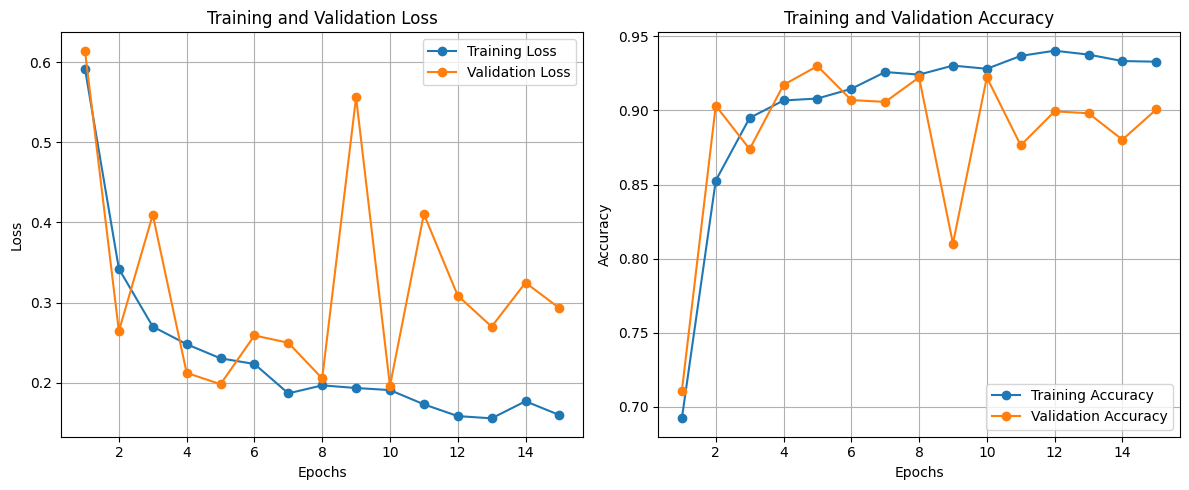

In [ ]:
# Plot Loss vs Epochs

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


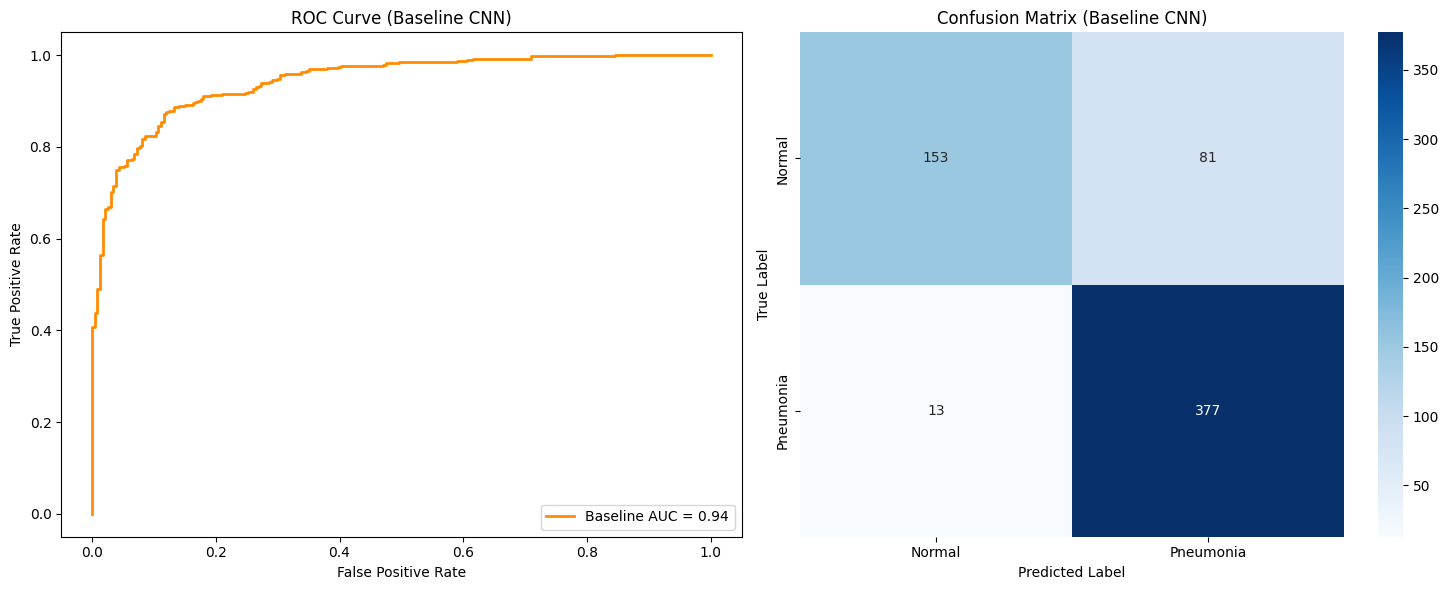

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate Predictions
y_true_cnn = []
y_pred_probs_cnn = []

# Ensure test_ds and model are defined before running this!
for images, labels in test_ds:
    preds = model.predict(images).ravel()
    y_pred_probs_cnn.extend(preds)
    y_true_cnn.extend(labels.numpy())

y_true_cnn = np.array(y_true_cnn)
y_pred_probs_cnn = np.array(y_pred_probs_cnn)
y_pred_labels_cnn = (y_pred_probs_cnn >= 0.5).astype(int)

# 2. Metrics
fpr_c, tpr_c, _ = roc_curve(y_true_cnn, y_pred_probs_cnn)
roc_auc_c = auc(fpr_c, tpr_c)
cm_cnn = confusion_matrix(y_true_cnn, y_pred_labels_cnn)

# 3. Plotting
plt.figure(figsize=(15, 6))

# ROC Curve Subplot
plt.subplot(1, 2, 1)
plt.plot(fpr_c, tpr_c, color='darkorange', lw=2, label=f'Baseline AUC = {roc_auc_c:.2f}')
plt.plot(color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Baseline CNN)')
plt.legend(loc="lower right")

# Confusion Matrix Subplot
plt.subplot(1, 2, 2)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Baseline CNN)')

plt.tight_layout()
plt.show()

The training and validation loss curves both show a clear downward trend, indicating that the model is successfully learning to minimize errors over the six epochs.  While the training accuracy improves steadily, the validation accuracy exhibits some volatility between epochs three and five, suggesting slight instability during the learning process. The final convergence of the validation and training lines indicates that the model is likely well-fit and generalizing well to new data rather than overfitting.

             STRESS TEST: MIRRORED IMAGES REPORT
MIRRORED TEST ACCURACY:  82.53%
MIRRORED TEST PRECISION: 79.70%
MIRRORED TEST RECALL:    96.67%
-----------------------------------------------------------------

DETAILED PERFORMANCE TABLE (MIRRORED):
              precision    recall  f1-score   support

      Normal       0.91      0.59      0.72       234
   Pneumonia       0.80      0.97      0.87       390

    accuracy                           0.83       624
   macro avg       0.86      0.78      0.80       624
weighted avg       0.84      0.83      0.81       624



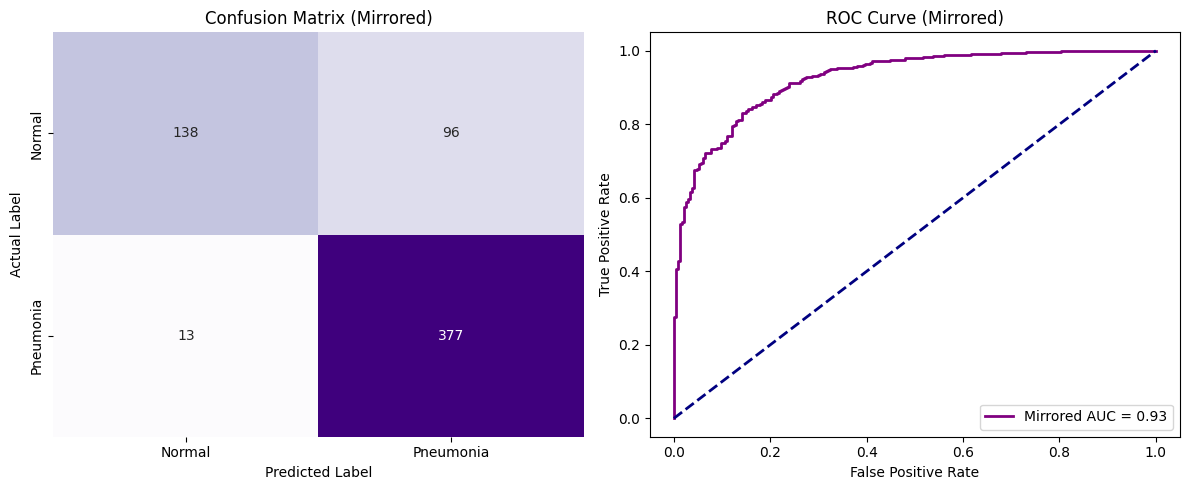

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the full mirrored test set
# Using .flip(axis=2) to handle (height, width, channels)
X_test_mirrored = np.flip(X_test, axis=2)

# 2. Get predictions for mirrored images
y_mirr_probs = model.predict(X_test_mirrored, verbose=0)
y_mirr_pred = (y_mirr_probs > 0.5).astype("int32")

# 3. Calculate individual metrics for the summary
acc_m = accuracy_score(y_test, y_mirr_pred)
prec_m = precision_score(y_test, y_mirr_pred)
rec_m = recall_score(y_test, y_mirr_pred)

# 4. CLEAR SUMMARY SECTION
print("="*65)
print("             STRESS TEST: MIRRORED IMAGES REPORT")
print("="*65)
print(f"MIRRORED TEST ACCURACY:  {acc_m*100:.2f}%")
print(f"MIRRORED TEST PRECISION: {prec_m*100:.2f}%")
print(f"MIRRORED TEST RECALL:    {rec_m*100:.2f}%")
print("-" * 65)

# 5. PERFORMANCE TABLE
print("\nDETAILED PERFORMANCE TABLE (MIRRORED):")
print(classification_report(y_test, y_mirr_pred, target_names=['Normal', 'Pneumonia']))
print("="*65)

# 6. VISUALIZATION: Confusion Matrix & ROC Curve
plt.figure(figsize=(12, 5))

# Confusion Matrix (Using Purples to distinguish from the standard test)
plt.subplot(1, 2, 1)
cm_mirr = confusion_matrix(y_test, y_mirr_pred)
sns.heatmap(cm_mirr, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix (Mirrored)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# ROC Curve
plt.subplot(1, 2, 2)
fpr_m, tpr_m, _ = roc_curve(y_test, y_mirr_probs)
roc_auc_m = auc(fpr_m, tpr_m)

plt.plot(fpr_m, tpr_m, color='purple', lw=2, label=f'Mirrored AUC = {roc_auc_m:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Mirrored)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

###"Cloudy" Image Test

          CLINICAL STRESS TEST: CLOUDY CONSOLIDATION
TEST ACCURACY:  71.79%
TEST PRECISION: 69.11%
TEST RECALL:    99.23%
-----------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.95      0.26      0.41       234
   Pneumonia       0.69      0.99      0.81       390

    accuracy                           0.72       624
   macro avg       0.82      0.63      0.61       624
weighted avg       0.79      0.72      0.66       624



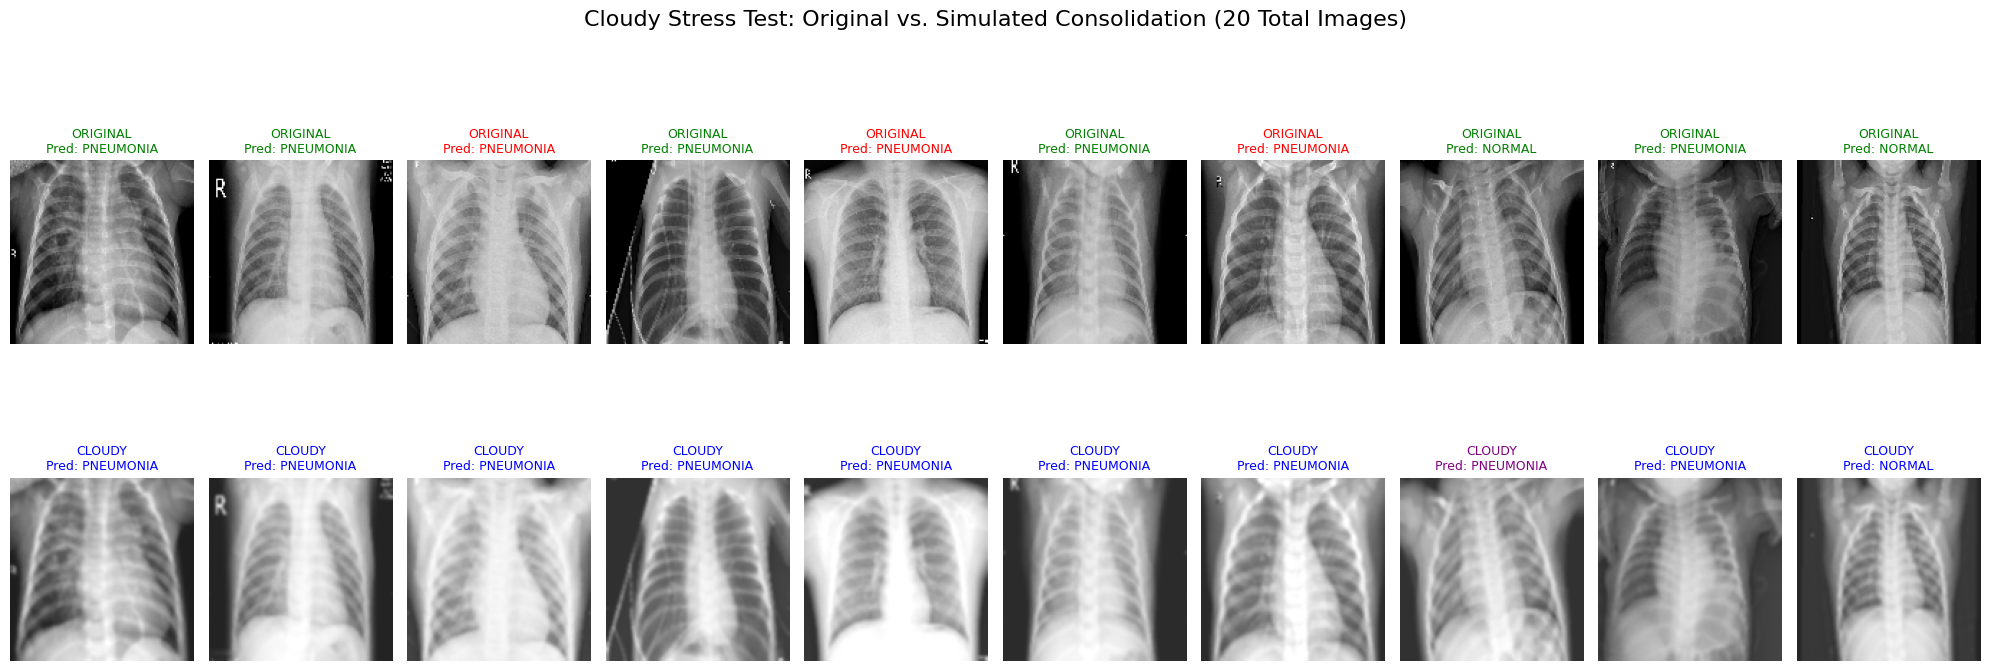

In [ ]:
# 6. Stress Test: Performance on 'Cloudy' Images (Consolidation Simulation)
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_score, recall_score, accuracy_score

# Mapping for the titles
label_map = {0: 'NORMAL', 1: 'PNEUMONIA'}

def apply_cloudiness(img):
    """Simulates clinical fluid buildup/consolidation."""
    haze = np.random.uniform(0.1, 0.2)
    cloudy_img = cv2.add(img, haze)
    cloudy_img = cv2.GaussianBlur(cloudy_img, (5, 5), 0)
    return cloudy_img.reshape(img.shape)

# 1. Identify variables in memory
test_data = X_test if 'X_test' in locals() else x_test
test_labels = Y_test if 'Y_test' in locals() else y_test

# 2. Create the full clouded test set for metrics
x_test_cloudy = np.array([apply_cloudiness(img) for img in test_data])

# 3. Get predictions for the report
cloudy_probs = model.predict(x_test_cloudy, verbose=0)
cloudy_preds = (cloudy_probs > 0.5).astype("int32")

# 4. PRINT METRICS (The Table)
acc = accuracy_score(test_labels, cloudy_preds)
prec = precision_score(test_labels, cloudy_preds)
rec = recall_score(test_labels, cloudy_preds)

print("="*65)
print("          CLINICAL STRESS TEST: CLOUDY CONSOLIDATION")
print("="*65)
print(f"TEST ACCURACY:  {acc*100:.2f}%")
print(f"TEST PRECISION: {prec*100:.2f}%")
print(f"TEST RECALL:    {rec*100:.2f}%")
print("-" * 65)
print(classification_report(test_labels, cloudy_preds, target_names=['Normal', 'Pneumonia']))
print("="*65)

# 5. VISUALIZATION (Matching your Mirror Test layout)
num_samples = 10
indices = np.random.choice(len(test_data), num_samples, replace=False)

plt.figure(figsize=(20, 8))
for i, idx in enumerate(indices):
    img_original = test_data[idx]
    actual_label_text = label_map[int(test_labels[idx])]
    img_cloudy = x_test_cloudy[idx]

    # Original Prediction
    p_orig = model.predict(np.expand_dims(img_original, axis=0), verbose=0)[0][0]
    l_orig = label_map[int(p_orig > 0.5)]

    # Cloudy Prediction
    p_clou = model.predict(np.expand_dims(img_cloudy, axis=0), verbose=0)[0][0]
    l_clou = label_map[int(p_clou > 0.5)]

    # Row 1: Original
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(img_original.squeeze(), cmap='gray')
    plt.title(f"ORIGINAL\nPred: {l_orig}", color='green' if l_orig == actual_label_text else 'red', fontsize=9)
    plt.axis('off')

    # Row 2: Cloudy
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.imshow(img_cloudy.squeeze(), cmap='gray')
    plt.title(f"CLOUDY\nPred: {l_clou}", color='blue' if l_orig == l_clou else 'purple', fontsize=9)
    plt.axis('off')

plt.suptitle("Cloudy Stress Test: Original vs. Simulated Consolidation (20 Total Images)", fontsize=16)
plt.tight_layout()
plt.show()

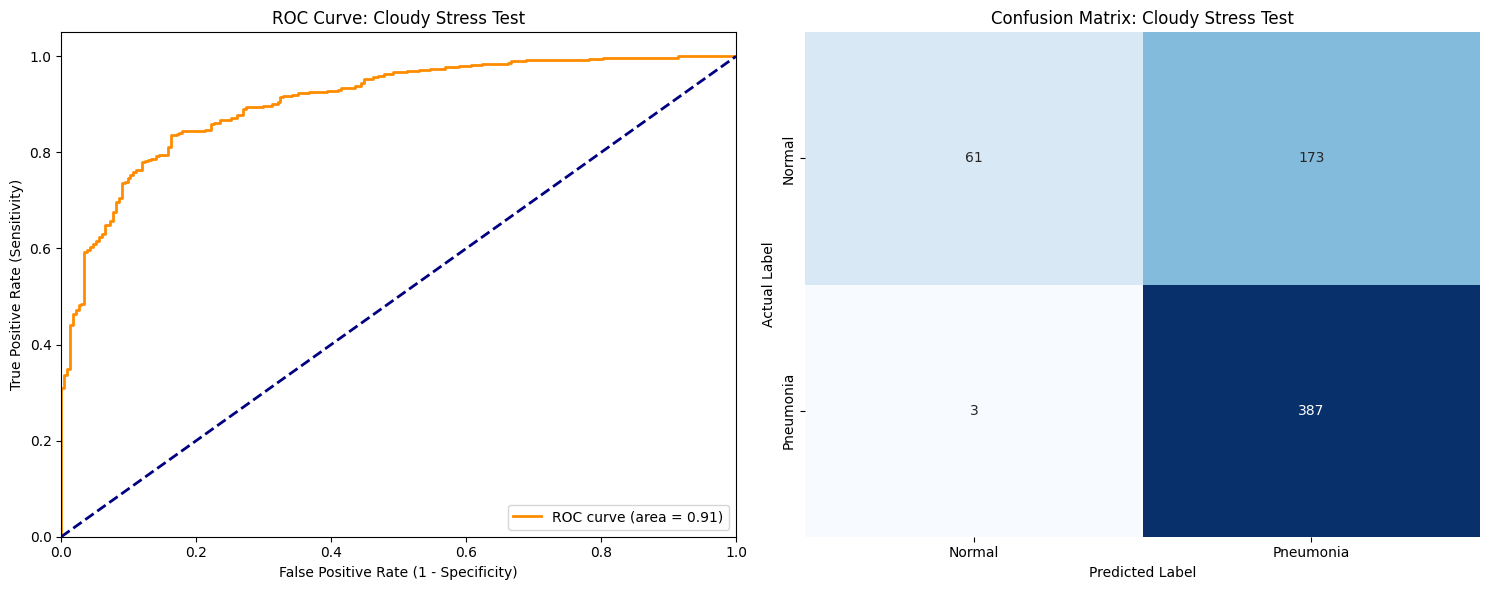

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

# 1. Calculate ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(test_labels, cloudy_probs)
roc_auc = auc(fpr, tpr)

# 2. Generate Confusion Matrix
cm = confusion_matrix(test_labels, cloudy_preds)

# 3. Create the plots
plt.figure(figsize=(15, 6))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: Cloudy Stress Test')
plt.legend(loc="lower right")

# Subplot 2: Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix: Cloudy Stress Test')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Confusion matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step


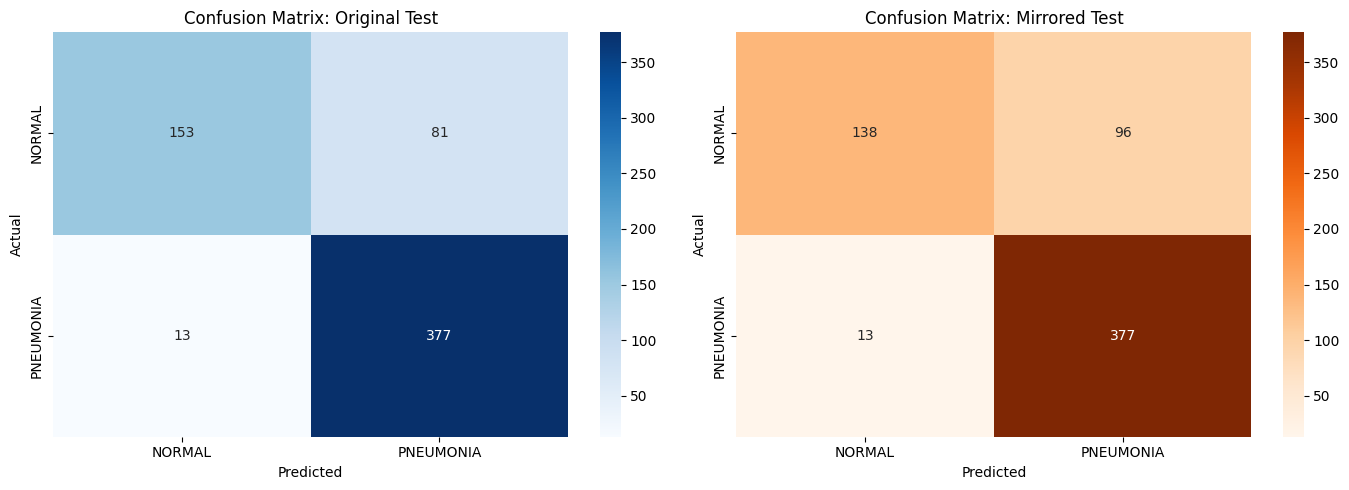

In [ ]:
# import seaborn as sns
# from sklearn.metrics import confusion_matrix

# def plot_cm_comparison(y_true, y_pred_orig, y_pred_mirr):
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     # Calculate matrices
#     cm_orig = confusion_matrix(y_true.astype(int), y_pred_orig)
#     cm_mirr = confusion_matrix(y_true.astype(int), y_pred_mirr)

#     labels = ["NORMAL", "PNEUMONIA"]

#     # Plot Original
#     sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0],
#                 xticklabels=labels, yticklabels=labels)
#     axes[0].set_title('Confusion Matrix: Original Test')
#     axes[0].set_xlabel('Predicted')
#     axes[0].set_ylabel('Actual')

#     # Plot Mirrored
#     sns.heatmap(cm_mirr, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
#                 xticklabels=labels, yticklabels=labels)
#     axes[1].set_title('Confusion Matrix: Mirrored Test')
#     axes[1].set_xlabel('Predicted')
#     axes[1].set_ylabel('Actual')

#     plt.tight_layout()
#     plt.show()

# plot_cm_comparison(y_test, y_pred, y_pred_m)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. EXTRACT TRUE LABELS AND GENERATE PREDICTIONS
# We pull the labels directly from the dataset to ensure we have all 624
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Generate predictions for Original
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Generate predictions for Mirrored
y_pred_mirrored_probs = model.predict(test_mirror_ds)
y_pred_mirrored = (y_pred_mirrored_probs > 0.5).astype(int).flatten()

# 2. PLOTTING FUNCTION
def plot_cm_comparison(y_true, y_pred_orig, y_pred_mirr):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    labels = ["NORMAL", "PNEUMONIA"]

    # Calculate matrices
    cm_orig = confusion_matrix(y_true, y_pred_orig)
    cm_mirr = confusion_matrix(y_true, y_pred_mirr)

    # Plot Original
    sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels)
    axes[0].set_title('Confusion Matrix: Original Test')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # Plot Mirrored
    sns.heatmap(cm_mirr, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=labels, yticklabels=labels)
    axes[1].set_title('Confusion Matrix: Mirrored Test')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

# 3. RUN THE PLOT
# Use the freshly extracted 'y_true'
plot_cm_comparison(y_true, y_pred, y_pred_mirrored)

### ResNet50

ResNet expects all images to be of shape (224, 224, 3). This means that we have to resize all our images to be of size 224 x 224 pixels. Furthermore, since our dataset consists of grayscale X-rays, we must convert them to RGB format to amtch ResNet's expected 3-channel input. We will use Keras and its ImageDataGenerator to handle preprocessing/augmentation. Pixel values will be rescaled/standardized using ImageNet normalization, rather than just [0,1] scaling because this ensures that our input data follows the same distribution that the ResNet50 images were trained on originally. In order to help our model generalize better given that we have a small dataset, we will apply data augmentation in two ways. First, we will use on-the-fly augmentation during training (random rotations/zooms/brightness shifts) to allow the model to see different variations of the training images. If needed, we will also add bootstrapped augmented copies to the Normal class (which is a minority) prior to training, which would help us reduce the class imbalance we see. Lastly, during model training, we will use class weights that are calculated in the preprocessing stage to further address the imbalance between Normal and Pneumonia samples.

In [ ]:
# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.10),
])

def make_dataset(X, y, training=False, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
        ds = ds.shuffle(len(X))

    # Map function: Resizes to 224x224 AND applies augmentation if training
    ds = ds.map(
        lambda x, y: (
            data_augmentation(tf.image.resize(x, [224, 224]), training=True) if training
            else tf.image.resize(x, [224, 224]),
            y
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Generate final datasets
train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

In [ ]:
# 1. Load Pre-trained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 2. Build Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# 3. Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# 4. Callbacks
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Psych 186B Final Project/best_resnet_baseline.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# 5. Train Phase 1
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5113 - loss: 0.7509 - precision: 0.5194 - recall: 0.5256
Epoch 1: val_accuracy improved from None to 0.25732, saving model to /content/drive/MyDrive/Psych 186B Final Project/best_resnet_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Psych 186B Final Project/best_resnet_baseline.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 523s 7s/step - accuracy: 0.5048 - loss: 0.7417 - precision: 0.5047 - recall: 0.5135 - val_accuracy: 0.2573 - val_loss: 0.7032 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5317 - loss: 0.7061 - precision: 0.5356 - recall: 0.4719
Epoch 2: val_accuracy did not improve from 0.25732
72/72 ━━━━━━━━━━━━━━━━━━━━ 572s 7s/step - accuracy: 0.5314 - loss: 0.7017 - precision: 0.5340 - recall: 0.4935 - val_accuracy: 0.2573 - val_loss: 0.7071 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6s

In [ ]:
print("Evaluating model on the test dataset...")

# Extract true labels from the test dataset
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# Get prediction probabilities from the model
y_pred_prob = model.predict(test_ds).ravel()

# Convert probabilities to binary class predictions (Threshold = 0.5)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

Evaluating model on the test dataset...
20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step


In [ ]:
# Print the Classification Report
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_class, target_names=['Normal (0)', 'Pneumonia (1)']))


--- Classification Report ---
               precision    recall  f1-score   support

   Normal (0)       0.75      0.53      0.62       234
Pneumonia (1)       0.76      0.89      0.82       390

     accuracy                           0.76       624
    macro avg       0.76      0.71      0.72       624
 weighted avg       0.76      0.76      0.75       624



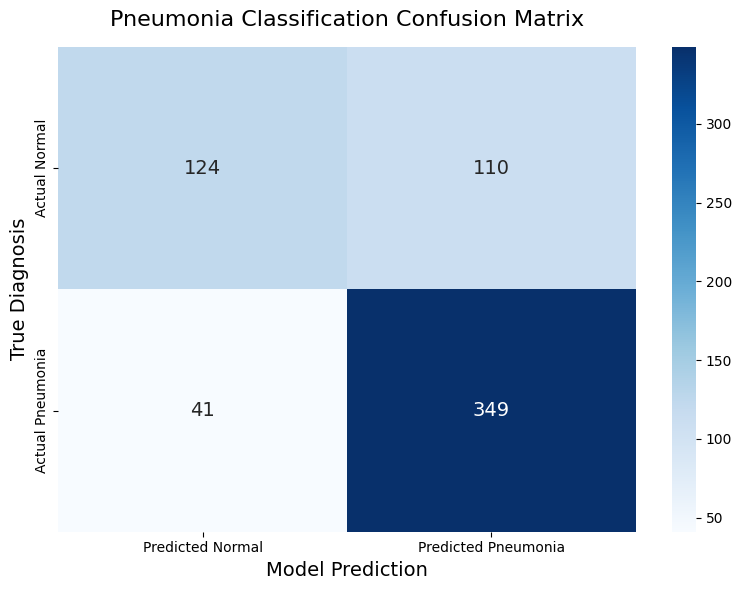

In [ ]:
# Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(8, 6))
# Using the 'Blues' colormap for a clean, academic look
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Pneumonia'],
            yticklabels=['Actual Normal', 'Actual Pneumonia'],
            annot_kws={"size": 14}) # Make the numbers larger for presentations

plt.title('Pneumonia Classification Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Diagnosis', fontsize=14)
plt.xlabel('Model Prediction', fontsize=14)
plt.tight_layout()
plt.show()

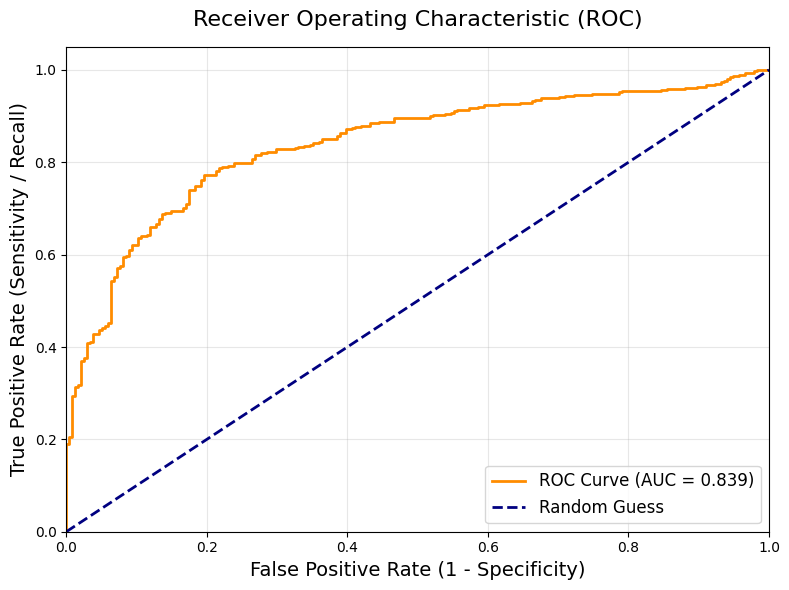

In [ ]:
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Fine Tuning

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 1. Unfreeze top layers
base_model.trainable = True
fine_tune_at = 143

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 2. Recompile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# Define the learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Watch the validation loss
    factor=0.5,           # Cut the learning rate in half (multiply by 0.5)
    patience=2,           # Do this if val_loss doesn't improve for 2 epochs
    min_lr=1e-6,          # Never drop the learning rate below this absolute minimum
    verbose=1             # Print a message when the learning rate drops
)

# 3. Train Phase 2
FINE_TUNE_EPOCHS = 10
total_epochs = EPOCHS + FINE_TUNE_EPOCHS

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7125 - loss: 0.6408 - precision: 0.7701 - recall: 0.5838
Epoch 10: val_accuracy did not improve from 0.82675
72/72 ━━━━━━━━━━━━━━━━━━━━ 789s 11s/step - accuracy: 0.8204 - loss: 0.4290 - precision: 0.8592 - recall: 0.7663 - val_accuracy: 0.2573 - val_loss: 0.9271 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9196 - loss: 0.2236 - precision: 0.9214 - recall: 0.9070
Epoch 11: val_accuracy did not improve from 0.82675
72/72 ━━━━━━━━━━━━━━━━━━━━ 743s 10s/step - accuracy: 0.9202 - loss: 0.2156 - precision: 0.9265 - recall: 0.9128 - val_accuracy: 0.2573 - val_loss: 0.8389 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9277 - loss: 0.1793 - precision: 0.9326 - recall: 0.9181
Epoch 12: val_accuracy did not improve from 0.82675
72/72 ━━━━━━━━━━━━━━━━━━━━ 786s 11s/step - accuracy: 0.9250 - loss:


Evaluation on ORIGINAL test set:
Test Accuracy:  0.8093
Test Precision: 0.7705
Test Recall:    0.9897
20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step


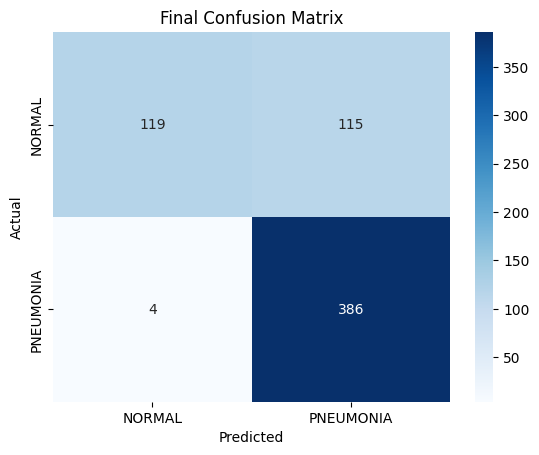

In [ ]:
# Evaluate on Test Data
print("\nEvaluation on ORIGINAL test set:")
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")

# Generate Confusion Matrix
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test.astype(int), y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
plt.title('Final Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

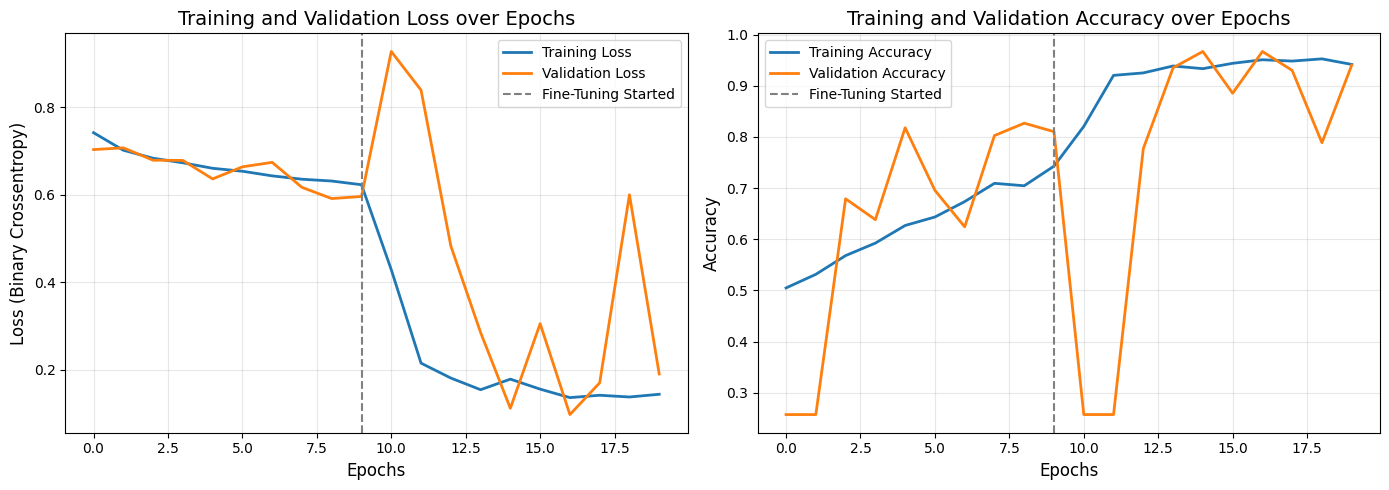

In [ ]:
def plot_combined_history(hist1, hist2, initial_epochs):
    # Combine metrics from Phase 1 and Phase 2
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

    plt.figure(figsize=(14, 5))

    # Plot Combined Loss
    plt.subplot(1, 2, 1)
    plt.plot(loss, label='Training Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss', linewidth=2)
    # Add a vertical line where fine-tuning started
    plt.axvline(x=initial_epochs-1, color='gray', linestyle='--', label='Fine-Tuning Started')
    plt.title('Training and Validation Loss over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (Binary Crossentropy)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot Combined Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(acc, label='Training Accuracy', linewidth=2)
    plt.plot(val_acc, label='Validation Accuracy', linewidth=2)
    plt.axvline(x=initial_epochs-1, color='gray', linestyle='--', label='Fine-Tuning Started')
    plt.title('Training and Validation Accuracy over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the graphing function
plot_combined_history(history, history_fine, EPOCHS)

20/20 ━━━━━━━━━━━━━━━━━━━━ 97s 5s/step


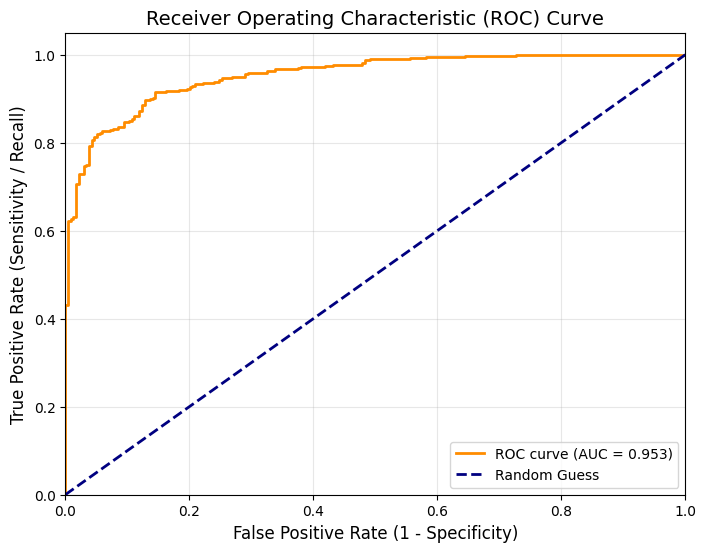

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get raw probabilities from the model
y_prob = model.predict(test_ds).ravel()

# Calculate False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


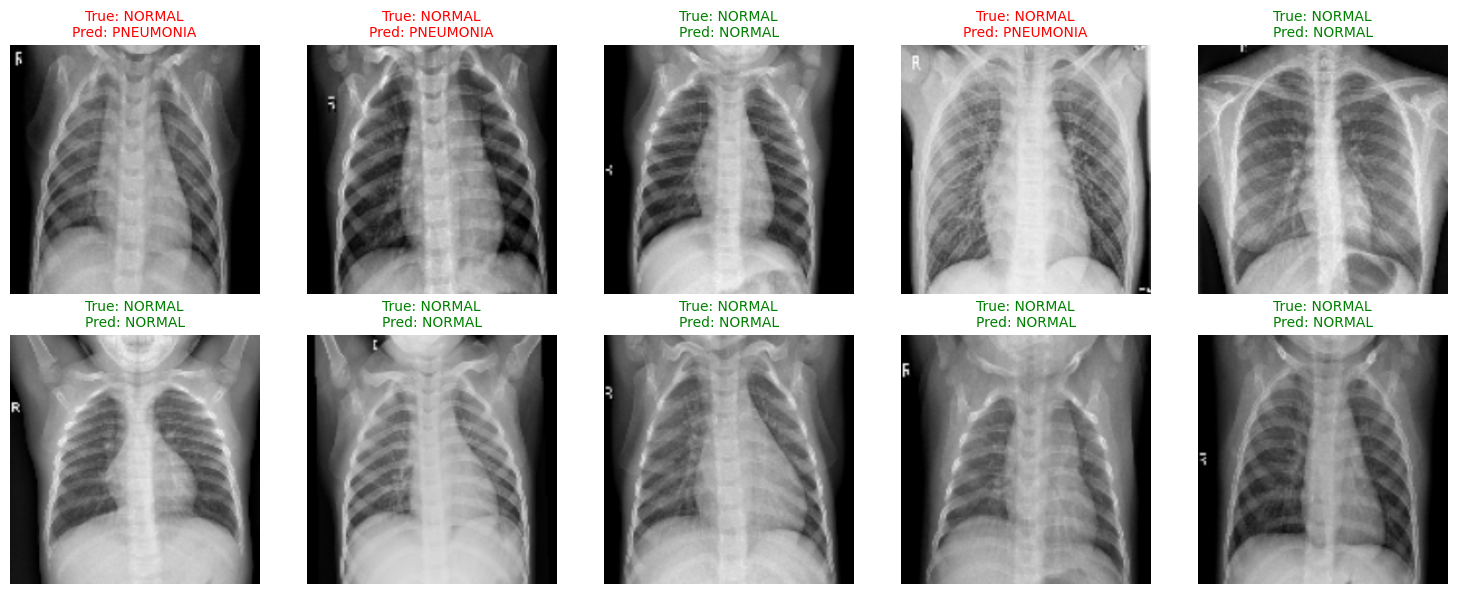

In [ ]:
# Take one batch of 32 images from the test dataset
for images, labels in test_ds.take(1):
    preds = model.predict(images).ravel()
    pred_classes = (preds >= 0.5).astype(int)
    true_classes = labels.numpy().astype(int)

    plt.figure(figsize=(15, 6))
    for i in range(10): # Show the first 10 images
        plt.subplot(2, 5, i+1)
        img_display = images[i].numpy()
        plt.imshow(img_display, cmap='gray')

        true_label = "PNEUMONIA" if true_classes[i] == 1 else "NORMAL"
        pred_label = "PNEUMONIA" if pred_classes[i] == 1 else "NORMAL"

        # Color code: Green for correct, Red for incorrect
        color = 'green' if true_classes[i] == pred_classes[i] else 'red'

        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Output only true=pneumonia to verify recall

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


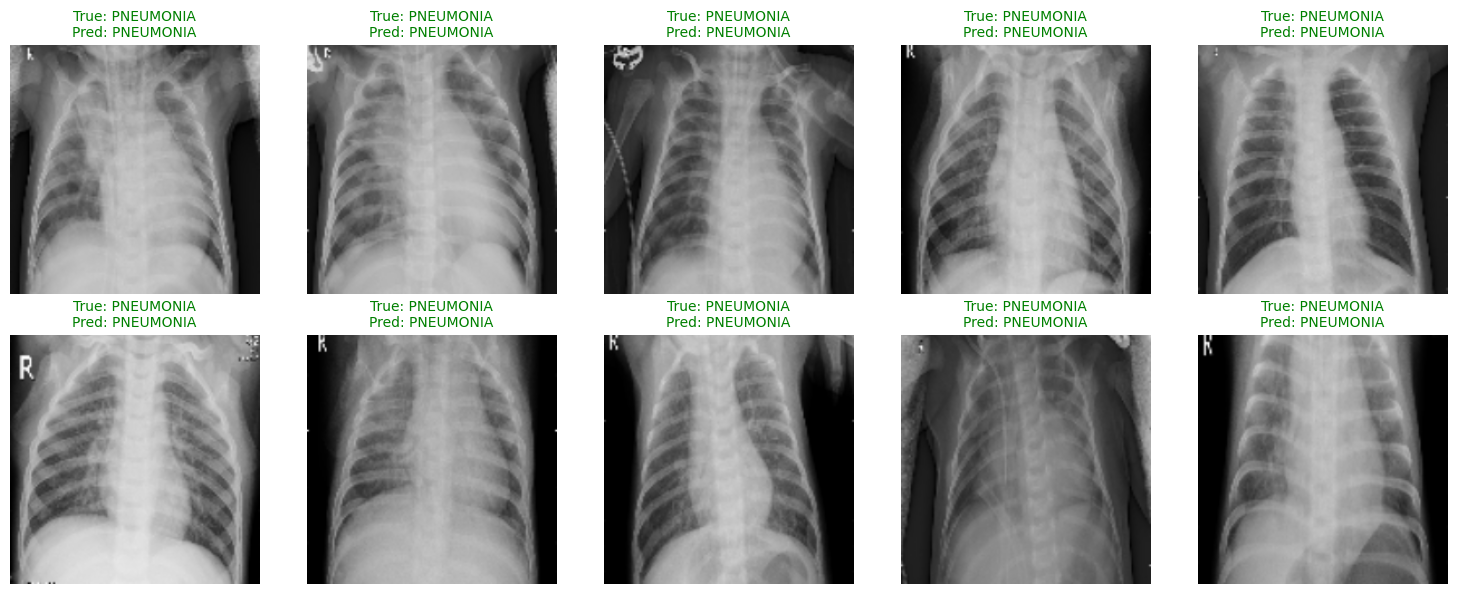

In [ ]:
# Take one batch of 32 images from the test dataset
for images, labels in test_ds.shuffle(200).take(1):
    preds = model.predict(images).ravel()
    pred_classes = (preds >= 0.5).astype(int)
    true_classes = labels.numpy().astype(int)

    # Find all indices in this batch where the true label is PNEUMONIA (1)
    pneumonia_indices = np.where(true_classes == 1)[0]

    num_to_display = min(10, len(pneumonia_indices))

    if num_to_display == 0:
        print("No True Pneumonia cases found in this batch.")
        continue

    plt.figure(figsize=(15, 6))

    for j in range(num_to_display):
        # Get the actual batch index for the pneumonia image
        i = pneumonia_indices[j]

        plt.subplot(2, 5, j+1)
        img_display = images[i].numpy()
        plt.imshow(img_display, cmap='gray')

        true_label = "PNEUMONIA"
        pred_label = "PNEUMONIA" if pred_classes[i] == 1 else "NORMAL"

        # Color code: Green for correct (True Positive), Red for incorrect (False Negative)
        color = 'green' if true_classes[i] == pred_classes[i] else 'red'

        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()